# Things to Learn
- Pandas
    -  Multindex
    - GroupBy
    - String Splice, Split, joins
- Left,right,center joins
- seaborn
- visualization (Choropleth, etc)


## PANDAS
 - Merge Vs. Concat
 - Left Merge
 - Right Merge
 - df.drop
 - df.iloc
 - .unstack
 - .stack
 - .rename

SEABORN
- Import libs: Pandas, seaborn(sns)
- pull data (pd.read_...)
- check data (head(5))
- read columns and observations
- types of plots:
    - Distribution Plot (sns.displot x = ..., kind = ... , hue = ... ,fill = T/F)
        - Y axis will be the count of the items
        - kind shows the type of chart (kde: kernel density estimation)
        - hue colors the plot based on a certain variable.
    - Count Plot (sns.countplot(x = ... data = df, hue = ..., palette = ...))
    - Box Plot (sns.boxplot(x = "..." , " y = "..."))
        - Similarly, Violin Plot (sns.vilionplot())
        


    



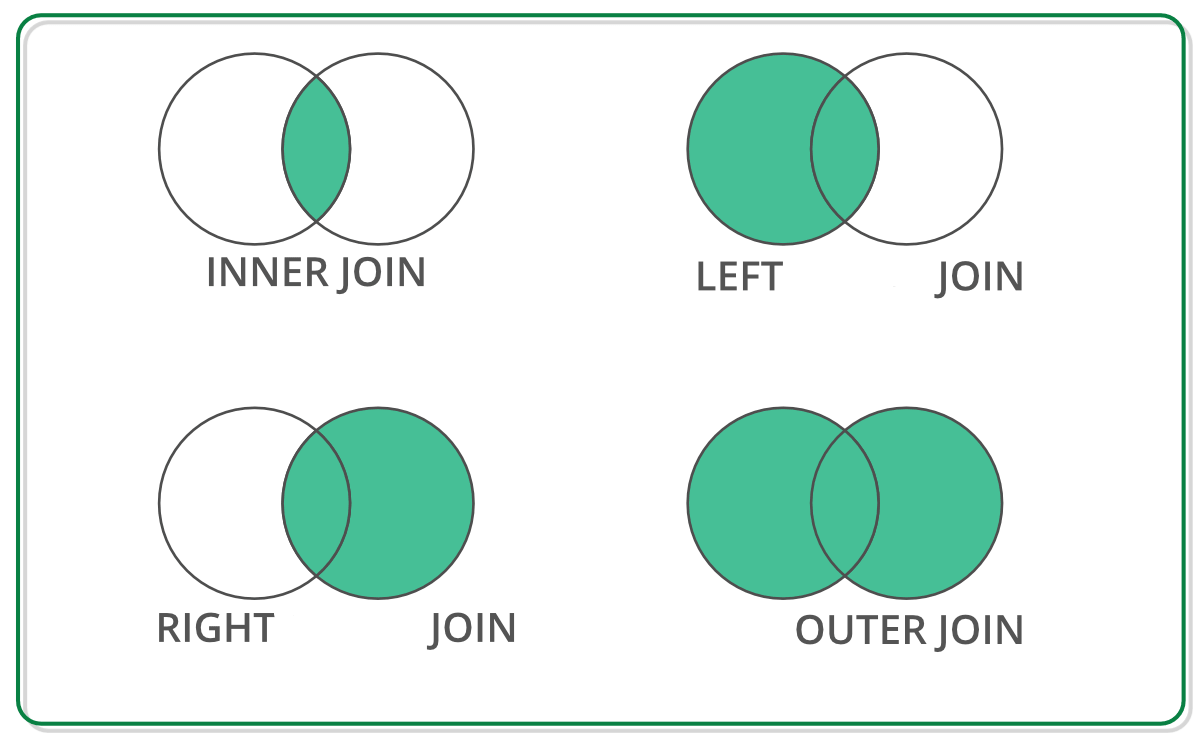

In [3]:
import pandas as pd
import os
os.chdir("/Users/jackson/Documents/ECON570")

In [4]:
df1 = pd.read_csv("data/nhe.csv")
df1.head()

,year,nhe
0,1960,27.1
1,1961,29.1
2,1962,31.8
3,1963,34.6
4,1964,38.2


In [5]:
df2 = pd.read_csv("data/nhe_cms.csv")
df2.head()

,year,nhe,consumption,personal,government,public_health,investment,population,gdp
0,1960,27.1,24.6,23.1,1.1,0.4,2.6,186,542.4
1,1961,29.1,26.2,24.6,1.2,0.4,2.9,189,562.2
2,1962,31.8,28.3,26.5,1.3,0.5,3.5,192,603.9
3,1963,34.6,30.8,29.0,1.3,0.5,3.8,195,637.5
4,1964,38.2,33.9,31.8,1.5,0.6,4.3,197,684.5


In [6]:
df1.merge(df2, how = 'inner',  on=["year"])
df1.head(6)

,year,nhe
0,1960,27.1
1,1961,29.1
2,1962,31.8
3,1963,34.6
4,1964,38.2
5,1965,.


In [7]:
df1.merge(df2 , how = 'outer',  on=["year"])

,year,nhe_x,nhe_y,consumption,personal,government,public_health,investment,population,gdp
0,1960,27.1,27.1,24.6,23.1,1.1,0.4,2.6,186,542.4
1,1961,29.1,29.1,26.2,24.6,1.2,0.4,2.9,189,562.2
2,1962,31.8,31.8,28.3,26.5,1.3,0.5,3.5,192,603.9
3,1963,34.6,34.6,30.8,29.0,1.3,0.5,3.8,195,637.5
4,1964,38.2,38.2,33.9,31.8,1.5,0.6,4.3,197,684.5
...,...,...,...,...,...,...,...,...,...,...
57,2017,3446.5,3446.5,3265.9,2903.8,266.6,95.5,180.6,325,19477.3
58,2018,3604.4,3604.4,3414.6,3019.8,295.4,99.4,189.9,327,20533.1
59,2019,3757.4,3757.4,3563.3,3173.1,283.2,107.1,194.1,328,21381.0
60,2020,4144.1,4144.1,3950.1,3367.0,344.9,238.3,193.9,329,21060.5


### Notice how there is an nhe_x and nhe_y? That is because there are multiple of the same columns, and outer join will give both cloumns, even if they are the exact same. 
#### The join of observations is on the year

- Left Merge
    - All left + matching right
- Right Merge
    - All Right + Matching Left
- Inner
    - Only matching keys 
- Outer
    - All keys from both left + right
        - Fills blanks with NaN



### df.loc() and df.iloc()

- iloc()
    - gets rows (or cols) at particular index positions
    - only takes ints
    - typical method of python slicing 
        - includes the first number, excludes the last
        - df.loc[0:3] would give rows 0,1,2. (doesnt include 3)

- loc()
    - Gets rows (or cols) at particular positions by using labels
    - uses exclusively labels.
        - A single label such as 5 is interpreted as the label of the index, never as an interger positon along the index.
    - Uses modified method of python indexing. 
        - Includes first number and last number
        - df.loc[0:3] would output rows 0,1,2,3
    




In [10]:
df1.iloc[0:3]
df2.iloc[0:10, 0:3]

,year,nhe,consumption
0,1960,27.1,24.6
1,1961,29.1,26.2
2,1962,31.8,28.3
3,1963,34.6,30.8
4,1964,38.2,33.9
5,1965,41.6,36.9
6,1966,45.8,40.8
7,1967,51.2,46.0
8,1968,58.0,52.2
9,1969,65.4,58.4


In [19]:
df2.loc[0:9,["consumption"]]

df2.loc[(df2.consumption > 300), ["gdp"]]

,gdp
22,3343.8
23,3634.0
24,4037.6
25,4339.0
26,4579.6
27,4855.2
28,5236.4
29,5641.6
30,5963.1
31,6158.1
